# 🏠 House Prices — Model Building

**Goal:** Train multiple models, evaluate with RMSLE (Kaggle metric), run cross-validation, and generate a Kaggle submission file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model   import Ridge, Lasso
from sklearn.pipeline       import make_pipeline
from sklearn.preprocessing  import RobustScaler
from sklearn.ensemble       import RandomForestRegressor
from sklearn.metrics        import root_mean_squared_error, r2_score
from xgboost                import XGBRegressor


## 1. Load Data

In [2]:
X = pd.read_csv("../data/train_final.csv")
y = pd.read_csv("../data/target.csv").squeeze()   # ← log1p(SalePrice)

test_final = pd.read_csv("../data/test_final.csv")
test_ids   = pd.read_csv("../data/test_ids.csv").squeeze()

print("X shape        :", X.shape)
print("y shape        :", y.shape)
print("test_final shape:", test_final.shape)
print()
print("Target (y) — already log1p transformed")
print(y.describe())


X shape        : (1458, 297)
y shape        : (1458,)
test_final shape: (1459, 297)

Target (y) — already log1p transformed
count    1458.000000
mean       12.024015
std         0.399713
min        10.460271
25%        11.774720
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice, dtype: float64


## 2. Train / Validation Split

In [3]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)


X_train: (1166, 297)
X_valid: (292, 297)


## 3. Helper — Evaluate Model

Since `y` is already log1p, RMSE here **is** RMSLE — the exact Kaggle metric.

In [4]:
def evaluate(name, model, X_tr, y_tr, X_val, y_val):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    rmsle = root_mean_squared_error(y_val, preds)
    r2    = r2_score(y_val, preds)
    print(f"{name:30s} | RMSLE: {rmsle:.5f} | R²: {r2:.4f}")
    return rmsle, r2


## 4. Cross-Validation Helper

5-Fold CV gives more reliable score than single val split.

In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_score(name, model):
    scores = -cross_val_score(
        model, X, y, cv=kf,
        scoring="neg_root_mean_squared_error"
    )
    print(f"{name:30s} | CV RMSLE: {scores.mean():.5f} ± {scores.std():.5f}")
    return scores.mean()


## 5. Model 1 — Ridge Regression

In [6]:
ridge = make_pipeline(RobustScaler(), Ridge(alpha=10))

ridge_rmsle, ridge_r2 = evaluate("Ridge", ridge, X_train, y_train, X_valid, y_valid)
ridge_cv = cv_score("Ridge (CV)", make_pipeline(RobustScaler(), Ridge(alpha=10)))


Ridge                          | RMSLE: 0.11541 | R²: 0.9210
Ridge (CV)                     | CV RMSLE: 0.11196 ± 0.00846


## 6. Model 2 — Lasso Regression

In [7]:
lasso = make_pipeline(RobustScaler(), Lasso(alpha=0.0005, max_iter=10000))

lasso_rmsle, lasso_r2 = evaluate("Lasso", lasso, X_train, y_train, X_valid, y_valid)
lasso_cv = cv_score("Lasso (CV)", make_pipeline(RobustScaler(), Lasso(alpha=0.0005, max_iter=10000)))


Lasso                          | RMSLE: 0.11068 | R²: 0.9273
Lasso (CV)                     | CV RMSLE: 0.10979 ± 0.00745


## 7. Model 3 — Random Forest

In [8]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)

rf_rmsle, rf_r2 = evaluate("Random Forest", rf_model, X_train, y_train, X_valid, y_valid)
rf_cv = cv_score("Random Forest (CV)", RandomForestRegressor(n_estimators=300, max_features=0.5, random_state=42, n_jobs=-1))


Random Forest                  | RMSLE: 0.13990 | R²: 0.8839
Random Forest (CV)             | CV RMSLE: 0.13133 ± 0.00787


## 8. Model 4 — XGBoost

In [9]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    objective="reg:squarederror",
    verbosity=0
)

xgb_rmsle, xgb_r2 = evaluate("XGBoost", xgb_model, X_train, y_train, X_valid, y_valid)
xgb_cv = cv_score("XGBoost (CV)", XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3,
                                                subsample=0.8, colsample_bytree=0.8,
                                                random_state=42, objective="reg:squarederror", verbosity=0))


XGBoost                        | RMSLE: 0.12092 | R²: 0.9133
XGBoost (CV)                   | CV RMSLE: 0.11653 ± 0.00430


## 9. Model Comparison

In [10]:
comparison = pd.DataFrame({
    "Model"     : ["Ridge", "Lasso", "Random Forest", "XGBoost"],
    "Val RMSLE" : [ridge_rmsle, lasso_rmsle, rf_rmsle, xgb_rmsle],
    "CV RMSLE"  : [ridge_cv,    lasso_cv,    rf_cv,    xgb_cv],
    "Val R²"    : [ridge_r2,    lasso_r2,    rf_r2,    xgb_r2],
})

comparison = comparison.sort_values("CV RMSLE").reset_index(drop=True)
print(comparison.to_string(index=False))


        Model  Val RMSLE  CV RMSLE   Val R²
        Lasso   0.110682  0.109792 0.927329
        Ridge   0.115406  0.111961 0.920995
      XGBoost   0.120917  0.116527 0.913268
Random Forest   0.139897  0.131333 0.883903


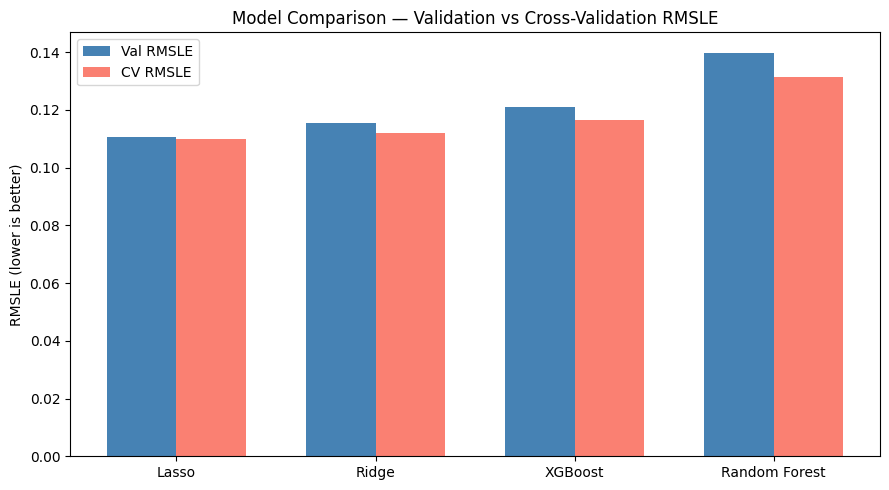

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison))
width = 0.35

ax.bar(x - width/2, comparison["Val RMSLE"], width, label="Val RMSLE", color="steelblue")
ax.bar(x + width/2, comparison["CV RMSLE"],  width, label="CV RMSLE",  color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"])
ax.set_ylabel("RMSLE (lower is better)")
ax.set_title("Model Comparison — Validation vs Cross-Validation RMSLE")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/plots/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Feature Importance — XGBoost

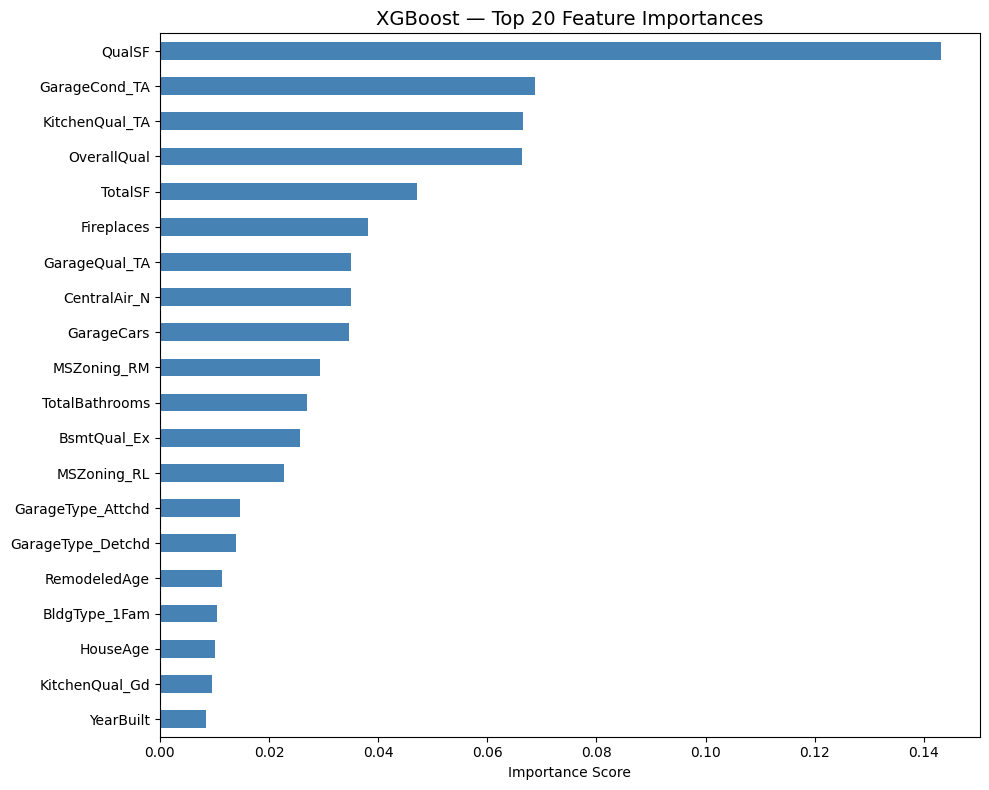

In [12]:
# Refit XGBoost on full training data for feature importance
xgb_model.fit(X, y)

feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
top20    = feat_imp.nlargest(20)

plt.figure(figsize=(10, 8))
top20.sort_values().plot(kind="barh", color="steelblue")
plt.title("XGBoost — Top 20 Feature Importances", fontsize=14)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../outputs/plots/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Residual Analysis

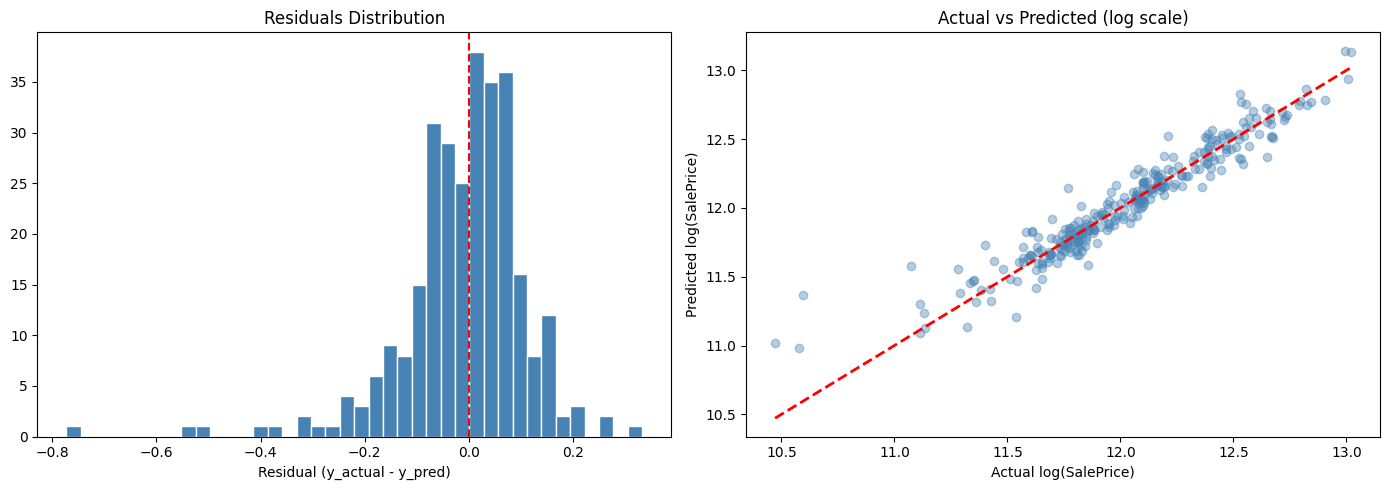

In [13]:
# Refit on train split for residual analysis
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_valid)
residuals  = y_valid.values - xgb_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution
axes[0].hist(residuals, bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Residuals Distribution")
axes[0].set_xlabel("Residual (y_actual - y_pred)")

# Actual vs Predicted
axes[1].scatter(y_valid, xgb_preds, alpha=0.4, color="steelblue")
axes[1].plot([y_valid.min(), y_valid.max()],
             [y_valid.min(), y_valid.max()], "r--", lw=2)
axes[1].set_title("Actual vs Predicted (log scale)")
axes[1].set_xlabel("Actual log(SalePrice)")
axes[1].set_ylabel("Predicted log(SalePrice)")

plt.tight_layout()
plt.savefig("../outputs/plots/residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Generate Kaggle Submission

⚠️ Predictions are in log scale — must convert back using `expm1()`.

In [14]:
# Refit best model on ALL training data before predicting test
xgb_model.fit(X, y)

test_pred_log = xgb_model.predict(test_final)
test_pred     = np.expm1(test_pred_log)   # convert back from log scale

submission = pd.DataFrame({
    "Id"       : test_ids,
    "SalePrice": test_pred
})

submission.to_csv("../submissions/submission_xgb.csv", index=False)

print("✅ Kaggle Submission File Created!")
print(submission.head(10))
print(f"\nSalePrice range: ${submission['SalePrice'].min():,.0f} — ${submission['SalePrice'].max():,.0f}")


✅ Kaggle Submission File Created!
     Id      SalePrice
0  1461  124509.617188
1  1462  160015.500000
2  1463  180583.031250
3  1464  197581.140625
4  1465  178319.734375
5  1466  176431.937500
6  1467  174847.031250
7  1468  170278.515625
8  1469  183810.125000
9  1470  127160.945312

SalePrice range: $38,525 — $628,613
